# 🌸 Iris Flower Classification

## Oasis Infobyte Data Science Internship

### Task 1

**Author:** Sahil Chauhan

---

## Objective

Build a Machine Learning model that predicts the species of an Iris flower based on four flower measurements.

---

## Dataset

Scikit-Learn Built-in Iris Dataset

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


# 2 Explore The Dataset


In [3]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
# Dispaly feature names of the iris dataset
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


# 3.Convert Data Set into Data Frame

In [6]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [7]:
# Add The Target column 
df["Species"]=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
# convert number into species name
df["Species"]=df["Species"].replace({
    0:"sertosa",
    1:"versicolor",
    2:"virginica"
})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,sertosa
1,4.9,3.0,1.4,0.2,sertosa
2,4.7,3.2,1.3,0.2,sertosa
3,4.6,3.1,1.5,0.2,sertosa
4,5.0,3.6,1.4,0.2,sertosa


# 4 Exploratory Data Analysis (EDA)

In [9]:
print("Data Set Shape:", df.shape)

# display data set information
df.info()

# check missing values
df.isnull().sum()

# display summary statistics
df.describe()

# count flower species
print(df["Species"].value_counts())

# display data set information
df.info()

# check mssing value
df.isnull().sum()

# dispaly summary stastics
df.describe()

# count flower species
print(df["Species"].value_counts())

Data Set Shape: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
Species
sertosa       50
versicolor    50
virginica     50
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 

# 5 Data Visualization

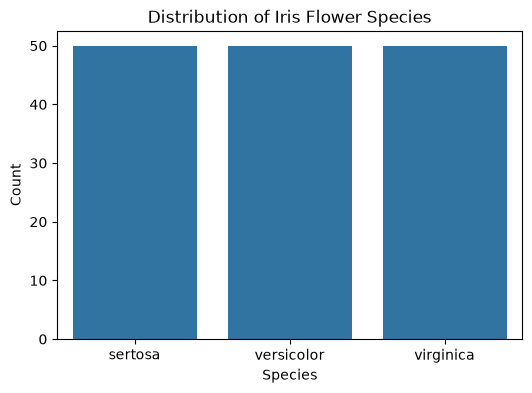

In [10]:
# count plot
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Species")

plt.title("Distribution of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

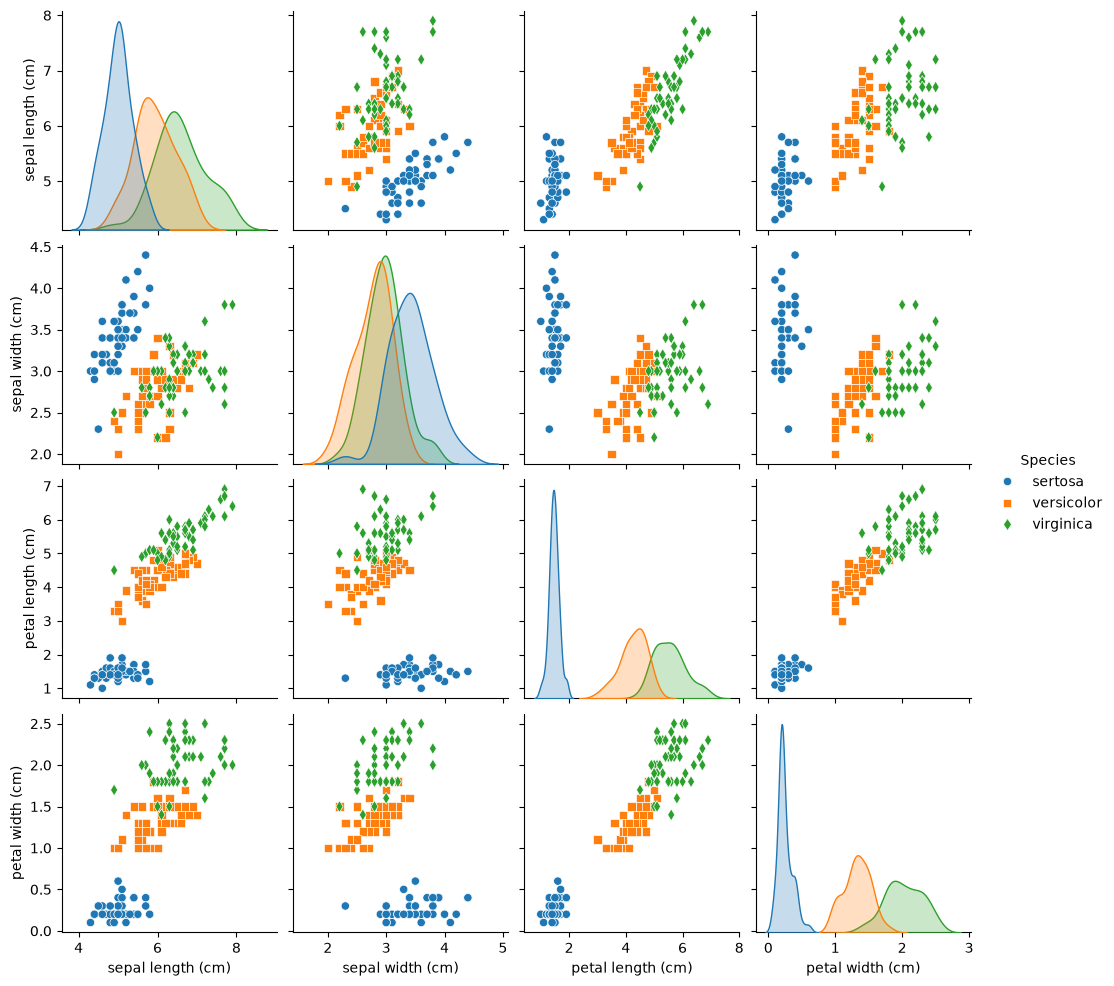

In [11]:
# pair plot
sns.pairplot(df, hue="Species",markers=["o","s","d"])
plt.show()

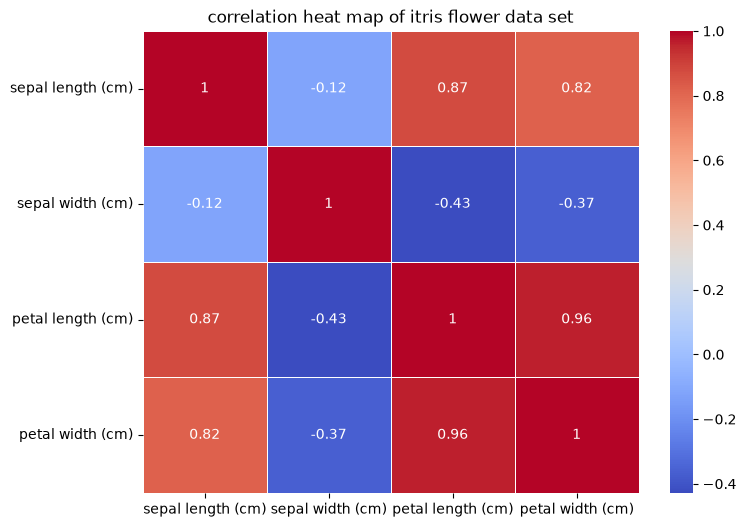

In [12]:
# correlation heat map

# select only numerical values
numerical_df=df.drop("Species",axis=1)

# calcualte correlation
correlation=numerical_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5
            )

plt.title("correlation heat map of itris flower data set")
plt.show()

# 6: Train-Test Split

In [13]:
# input features
X=df.drop("Species",axis=1)

# target varialble
y=df["Species"]

print("input features shape:",X.shape)
print("Target varialbe shape:",y.shape)

input features shape: (150, 4)
Target varialbe shape: (150,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print("Training features:",X_train.shape)
print("Testing features:",X_test.shape)
print("Training labels:",y_train.shape)
print("Testing labels:",y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training labels: (120,)
Testing labels: (30,)


# 7. Train the machine learning model

In [15]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
print("Decision Tree Model Train Successfully!")



Decision Tree Model Train Successfully!


# 8. make Prediction

In [19]:
# Predict the species of the test data
y_pred = model.predict(X_test)
print(y_pred[:10])

print("Predictions Completed Successfully!")
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

['versicolor' 'sertosa' 'virginica' 'versicolor' 'versicolor' 'sertosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
Predictions Completed Successfully!


,Actual,Predicted
0,versicolor,versicolor
1,sertosa,sertosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,sertosa,sertosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


# 9. Model Evaluation

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of The model:",accuracy)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

Accuracy of The model: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

     sertosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Evaluation

The Decision Tree Classifier achieved **100% accuracy** on the testing dataset.

The confusion matrix shows that all flower species were classified correctly with zero misclassifications.

The classification report indicates perfect precision, recall, and F1-score (1.00) for all three Iris species.

Overall, the model performs exceptionally well on the Iris dataset and is suitable for accurate flower species prediction.